# 📊 DXC Contact Center — Prédiction KPIs

**Cibles :** `offered`, `abandoned`, `avg_aht`, `asa`, `avg_hold`, `avg_ttc`  
**Modèles testés :** Prophet · SARIMA · XGBoost · LightGBM  
**Données :** `Telephony_Data.csv` — 250 K lignes, 151 queues, 2024-05 → 2026-05  
**Horizon de test :** 30 jours (backtest)

---
### 🏆 Résultats (MAPE backtest 30 jours)

| KPI | Meilleur modèle | MAPE |
|-----|----------------|------|
| **offered** | XGBoost | 35.8% |
| **abandoned** | LightGBM | 75.6% |
| **avg_aht** | **SARIMA** | **7.7%** |
| **asa** | XGBoost | 50.5% |
| **avg_hold** | **Prophet** | **15.2%** |
| **avg_ttc** | **SARIMA** | **9.2%** |

## 0. Installation & imports

In [4]:
# !pip install prophet lightgbm xgboost scikit-learn statsmodels matplotlib seaborn pandas numpy

import warnings, logging
warnings.filterwarnings('ignore')
logging.getLogger('prophet').setLevel(logging.ERROR)
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.metrics import mean_absolute_error, mean_squared_error
from prophet import Prophet
from statsmodels.tsa.statespace.sarimax import SARIMAX
import xgboost as xgb
import lightgbm as lgb

pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams.update({'figure.figsize': (14, 5), 'axes.grid': True, 'grid.alpha': 0.3})
print('✅ Imports OK')

✅ Imports OK


## 1. Chargement & nettoyage

In [5]:
CSV_PATH = '../data/Telephony_Data.csv'   

df = pd.read_csv(CSV_PATH, sep=';', dtype=str, low_memory=False)
df.columns = df.columns.str.strip().str.lstrip('\ufeff')
df['StartInterval'] = pd.to_datetime(df['StartInterval'], errors='coerce', utc=True)
df = df.dropna(subset=['StartInterval'])

NUM_COLS = {
    'Contacts queued':               'offered',
    'Contacts abandoned':            'abandoned',
    'Contacts handled incoming':     'answered',
    'Average handle time':           'avg_aht',
    'Average queue answer time':     'asa',
    'Average customer hold time':    'avg_hold',
    'Average agent interaction time':'avg_ttc',
}
for orig, new in NUM_COLS.items():
    df[new] = pd.to_numeric(df[orig].astype(str).str.replace(',','.'), errors='coerce').fillna(0).clip(lower=0)

df['date'] = df['StartInterval'].dt.tz_convert(None).dt.date
print(f'Lignes : {len(df):,}  Queues : {df["Queue"].nunique()}  '
      f'Période : {df["StartInterval"].min().date()} → {df["StartInterval"].max().date()}')

Lignes : 250,275  Queues : 151  Période : 2024-05-31 → 2026-05-02


## 2. Agrégation journalière

In [6]:
# Filtre optionnel
ACCOUNT_FILTER = None   # ex: 'Renault FR' | None = global toutes queues
QUEUE_FILTER   = None   # ex: 'Benelux_Dutch_Queue'

df_f = df.copy()
if ACCOUNT_FILTER: df_f = df_f[df_f.get('account', pd.Series(dtype=str)) == ACCOUNT_FILTER]
if QUEUE_FILTER:   df_f = df_f[df_f['Queue'] == QUEUE_FILTER]

def wavg(vals, weights):
    w = weights.clip(lower=0)
    return float((vals * w).sum() / w.sum()) if w.sum() > 0 else 0.0

daily_list = []
for date, g in df_f.groupby('date'):
    w = g['offered'].clip(lower=0)
    daily_list.append({
        'date':      pd.Timestamp(date),
        'offered':   g['offered'].sum(),
        'abandoned': g['abandoned'].sum(),
        'answered':  g['answered'].sum(),
        'avg_aht':   wavg(g['avg_aht'], w),
        'asa':       wavg(g['asa'], w),
        'avg_hold':  wavg(g['avg_hold'], w),
        'avg_ttc':   wavg(g['avg_ttc'], w),
    })

daily = pd.DataFrame(daily_list).sort_values('date').reset_index(drop=True)
daily = daily[daily['offered'] > 0]
daily = daily[daily['date'] >= '2025-01-01'].reset_index(drop=True)  # 2025+

TARGETS = ['offered','abandoned','avg_aht','asa','avg_hold','avg_ttc']
LABELS  = {'offered':'Appels offerts','abandoned':'Abandons',
            'avg_aht':'AHT (sec)','asa':'ASA (sec)',
            'avg_hold':'Avg Hold (sec)','avg_ttc':'Avg TTC (sec)'}

print(f'Jours : {len(daily)}  Période : {daily["date"].min().date()} → {daily["date"].max().date()}')
daily[TARGETS].describe()

Jours : 477  Période : 2025-01-01 → 2026-05-02


,offered,abandoned,avg_aht,asa,avg_hold,avg_ttc
count,477.00,477.00,477.00,477.00,477.00,477.00
mean,715.62,26.90,439.71,20.65,102.28,376.15
std,467.77,25.83,133.05,36.42,34.84,75.42
min,1.00,0.00,106.57,1.00,0.00,76.43
25%,207.00,9.00,387.00,8.98,93.13,336.12
50%,850.00,23.00,459.45,13.28,109.47,394.77
75%,1033.00,35.00,492.86,21.67,122.58,429.91
max,2748.00,210.00,2547.75,653.08,190.91,508.44


## 3. Visualisation exploratoire

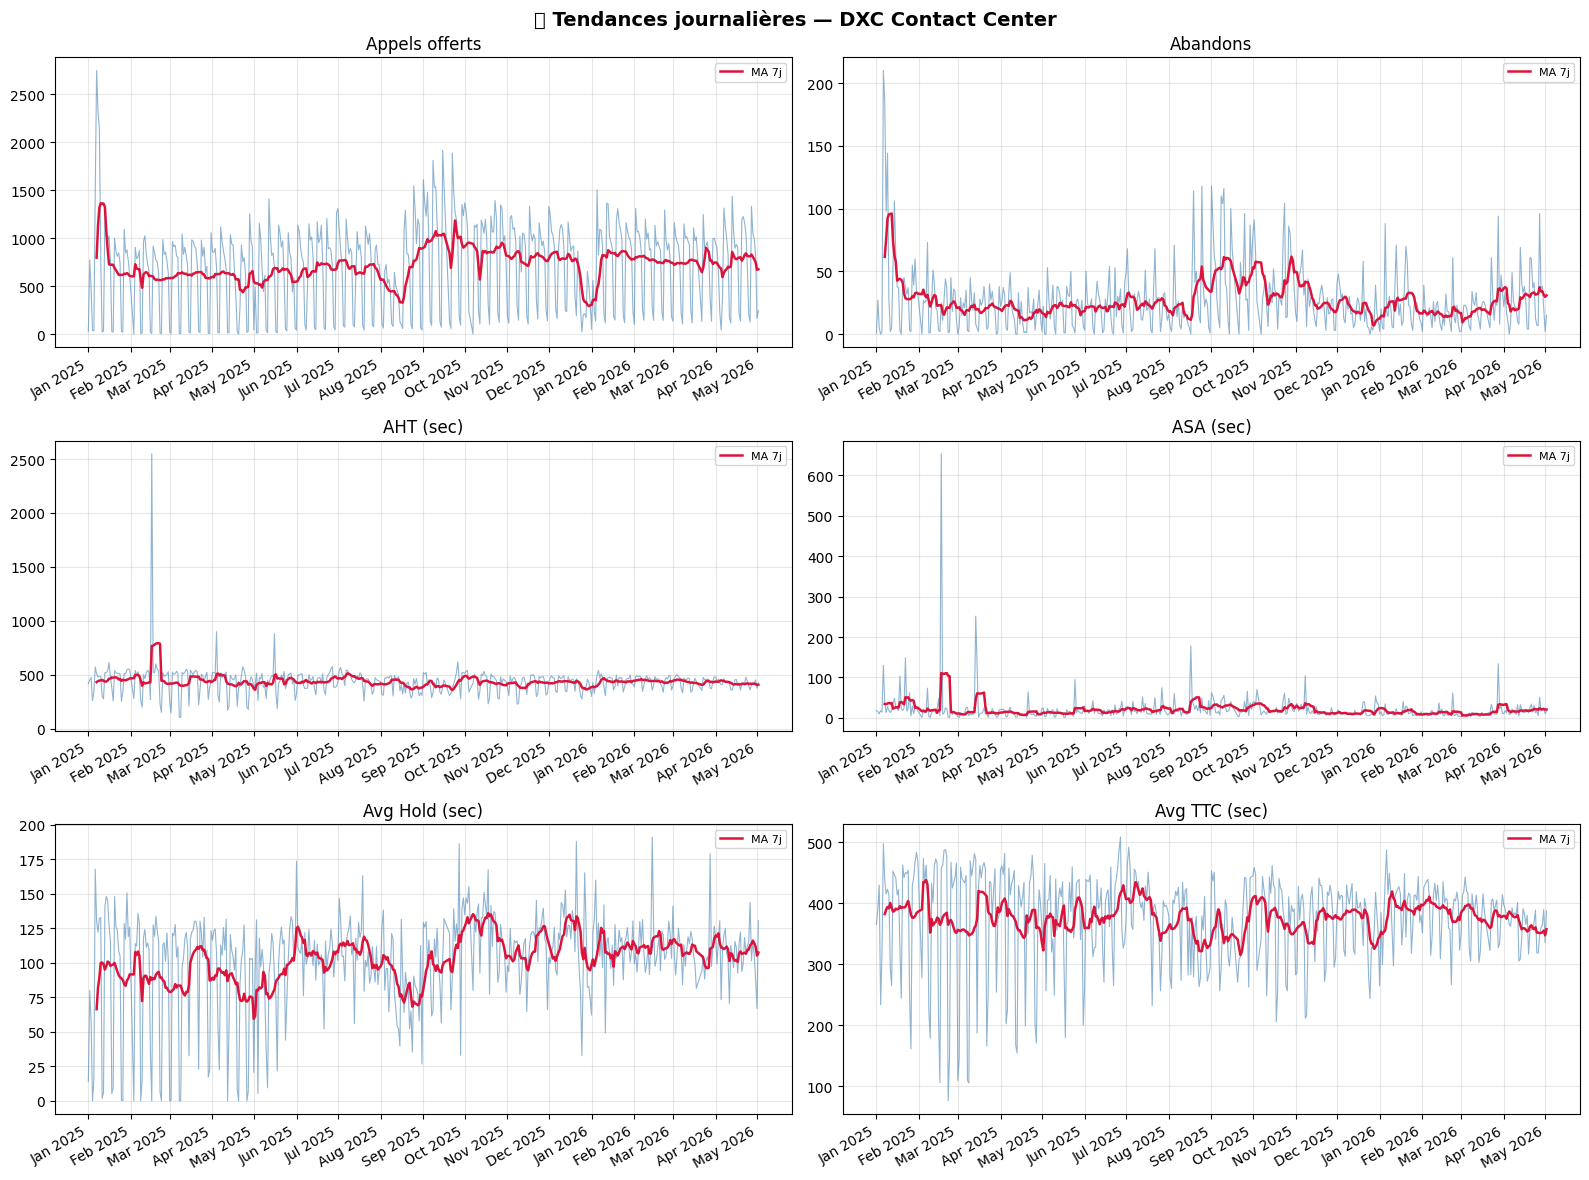

In [7]:
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
fig.suptitle('📈 Tendances journalières — DXC Contact Center', fontsize=14, fontweight='bold')
for ax, col in zip(axes.flat, TARGETS):
    ax.plot(daily['date'], daily[col], linewidth=0.8, color='steelblue', alpha=0.6)
    ax.plot(daily['date'], daily[col].rolling(7).mean(), color='crimson', linewidth=1.8, label='MA 7j')
    ax.set_title(LABELS[col])
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('kpi_trends.png', dpi=120, bbox_inches='tight')
plt.show()

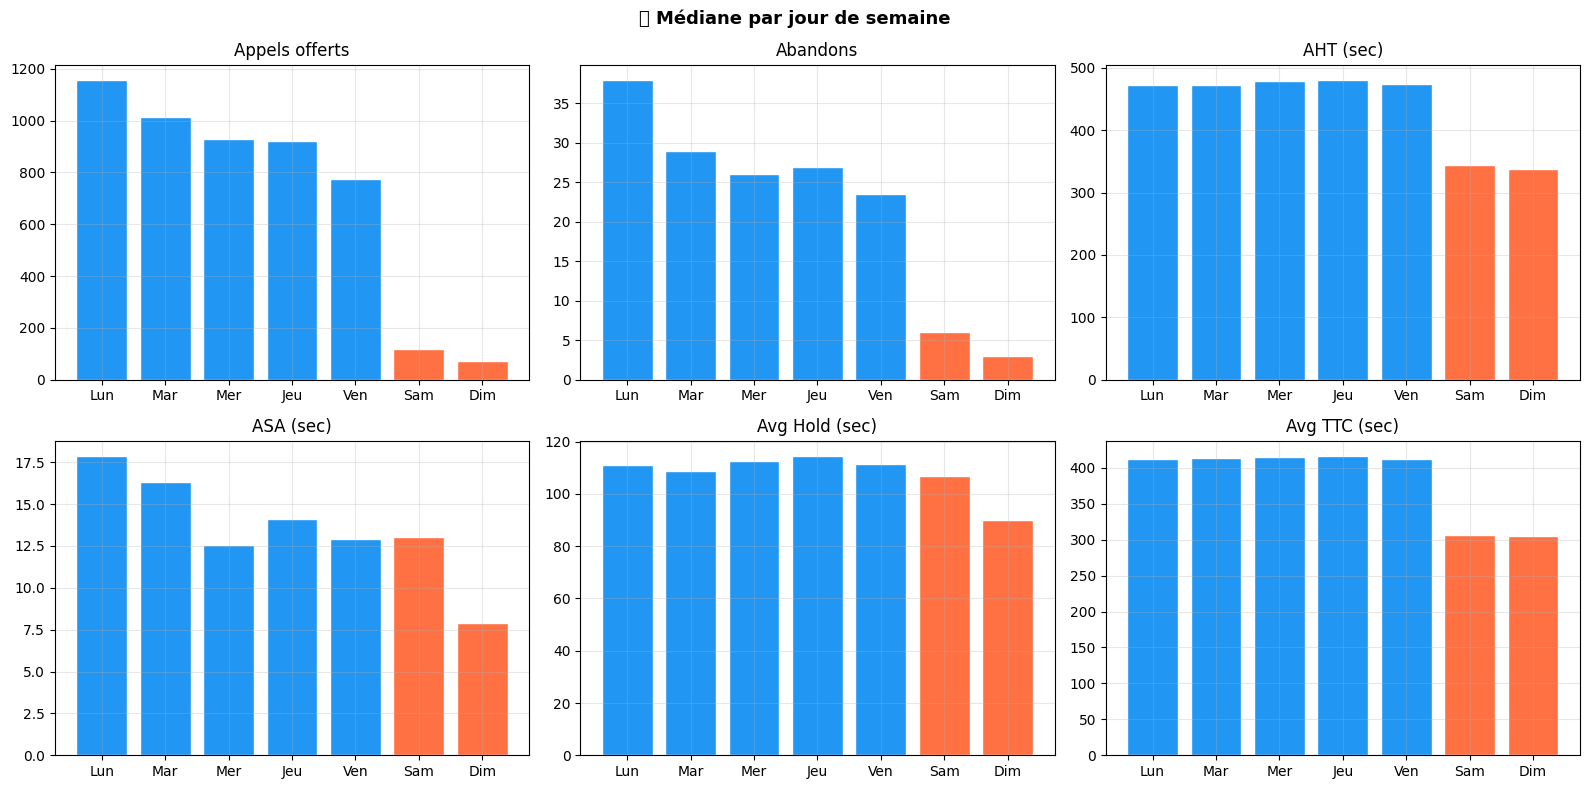

In [8]:
# Saisonnalité hebdomadaire
daily['dow'] = daily['date'].dt.dayofweek
dow_labels = ['Lun','Mar','Mer','Jeu','Ven','Sam','Dim']
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('📅 Médiane par jour de semaine', fontsize=13, fontweight='bold')
for ax, col in zip(axes.flat, TARGETS):
    med = daily.groupby('dow')[col].median()
    colors = ['#2196F3' if i<5 else '#FF7043' for i in range(7)]
    ax.bar(dow_labels, med.values, color=colors, edgecolor='white')
    ax.set_title(LABELS[col])
plt.tight_layout()
plt.savefig('kpi_weekly.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. Helpers — métriques & features

In [9]:
HORIZON = 30
COLORS  = {'Prophet':'#FF6B35','SARIMA':'#9B5DE5','XGBoost':'#00B4D8','LightGBM':'#2DC653'}

def mape(y_true, y_pred):
    mask = y_true > 0
    return float(np.mean(np.abs((y_true[mask]-y_pred[mask])/y_true[mask]))*100)

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def make_lag_features(ts_df):
    df = ts_df.copy()
    for lag in [1,2,3,7,14,21]: df[f'lag{lag}'] = df['y'].shift(lag)
    df['roll7']   = df['y'].shift(1).rolling(7).mean()
    df['roll14']  = df['y'].shift(1).rolling(14).mean()
    df['roll30']  = df['y'].shift(1).rolling(30).mean()
    df['dow']     = df['ds'].dt.dayofweek
    df['month']   = df['ds'].dt.month
    df['week']    = df['ds'].dt.isocalendar().week.astype(int)
    df['is_wknd'] = (df['dow']>=5).astype(int)
    return df.dropna()

print(f'✅ Horizon backtest : {HORIZON} jours')

✅ Horizon backtest : 30 jours


## 5. Entraînement & évaluation — 4 modèles × 6 KPIs

In [17]:
# ── Métriques ────────────────────────────────────────────────────────────────
def rmse(y, yhat):
    return np.sqrt(np.mean((np.array(y) - np.array(yhat))**2))

def mape(y, yhat):
    y, yhat = np.array(y), np.array(yhat)
    mask = y != 0
    return np.mean(np.abs((y[mask] - yhat[mask]) / y[mask])) * 100

def r2(y, yhat):
    return round(r2_score(y, yhat), 4)

# ── Boucle principale ─────────────────────────────────────────────────────────
all_results   = {}
all_forecasts = {}
all_true      = {}

for target in TARGETS:
    ts = daily[['date', target]].rename(columns={'date': 'ds', target: 'y'}).dropna()
    ts = ts[ts['y'] > 0].reset_index(drop=True)
    train, test = ts[:-HORIZON], ts[-HORIZON:]
    y_true = test['y'].values
    all_true[target] = y_true
    res, fcs = {}, {}

    # ── Prophet ──────────────────────────────────────────────────────────────
    try:
        m = Prophet(
            yearly_seasonality=True,
            weekly_seasonality=True,
            daily_seasonality=False,
            changepoint_prior_scale=0.05,
            seasonality_prior_scale=10
        )
        m.fit(train)
        fc = m.predict(m.make_future_dataframe(periods=HORIZON)).tail(HORIZON)['yhat'].values.clip(min=0)
        res['Prophet'] = {
            'mae':  round(mean_absolute_error(y_true, fc), 2),
            'rmse': round(rmse(y_true, fc), 2),
            'mape': round(mape(y_true, fc), 2),
            'r2':   r2(y_true, fc)
        }
        fcs['Prophet'] = fc
    except Exception as e:
        res['Prophet'] = {'mae': 9999, 'rmse': 9999, 'mape': 9999, 'r2': -9999, 'error': str(e)[:80]}

    # ── SARIMA ───────────────────────────────────────────────────────────────
    try:
        fit = SARIMAX(
            train['y'].values,
            order=(1, 1, 1),
            seasonal_order=(1, 1, 0, 7),
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit(disp=False, maxiter=80)
        fc_s = fit.forecast(HORIZON).clip(min=0)
        res['SARIMA'] = {
            'mae':  round(mean_absolute_error(y_true, fc_s), 2),
            'rmse': round(rmse(y_true, fc_s), 2),
            'mape': round(mape(y_true, fc_s), 2),
            'r2':   r2(y_true, fc_s)
        }
        fcs['SARIMA'] = fc_s
    except Exception as e:
        res['SARIMA'] = {'mae': 9999, 'rmse': 9999, 'mape': 9999, 'r2': -9999}

    # ── Features pour ML ─────────────────────────────────────────────────────
    tf = make_lag_features(ts)
    feat_cols = [c for c in tf.columns if c not in ['ds', 'y']]
    split = len(tf) - HORIZON
    X_tr, y_tr = tf[feat_cols].values[:split], tf['y'].values[:split]
    X_te, y_te = tf[feat_cols].values[split:], tf['y'].values[split:]

    # ── XGBoost ──────────────────────────────────────────────────────────────
    try:
        xm = xgb.XGBRegressor(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            verbosity=0
        )
        xm.fit(X_tr, y_tr)
        fc_x = xm.predict(X_te).clip(min=0)
        res['XGBoost'] = {
            'mae':  round(mean_absolute_error(y_te, fc_x), 2),
            'rmse': round(rmse(y_te, fc_x), 2),
            'mape': round(mape(y_te, fc_x), 2),
            'r2':   r2(y_te, fc_x)
        }
        fcs['XGBoost'] = fc_x
    except Exception as e:
        res['XGBoost'] = {'mae': 9999, 'rmse': 9999, 'mape': 9999, 'r2': -9999}

    # ── LightGBM ─────────────────────────────────────────────────────────────
    try:
        lm = lgb.LGBMRegressor(
            n_estimators=300,
            num_leaves=31,
            learning_rate=0.05,
            subsample=0.8,
            random_state=42,
            verbose=-1
        )
        lm.fit(X_tr, y_tr)
        fc_l = lm.predict(X_te).clip(min=0)
        res['LightGBM'] = {
            'mae':  round(mean_absolute_error(y_te, fc_l), 2),
            'rmse': round(rmse(y_te, fc_l), 2),
            'mape': round(mape(y_te, fc_l), 2),
            'r2':   r2(y_te, fc_l)
        }
        fcs['LightGBM'] = fc_l
    except Exception as e:
        res['LightGBM'] = {'mae': 9999, 'rmse': 9999, 'mape': 9999, 'r2': -9999}

    # ── Sauvegarde & affichage ────────────────────────────────────────────────
    all_results[target]   = res
    all_forecasts[target] = fcs
    best = min(res.items(), key=lambda x: x[1].get('mape', 9999))
    print(
        f'{target:12s} | 🏆 {best[0]:10s} '
        f'MAPE={best[1]["mape"]:.1f}%  '
        f'MAE={best[1]["mae"]}  '
        f'RMSE={best[1]["rmse"]}  '
        f'R²={best[1]["r2"]}'
    )

# ── Tableau récapitulatif ─────────────────────────────────────────────────────
print("\n" + "="*75)
print(f"{'Target':<14} {'Model':<12} {'MAE':>8} {'RMSE':>8} {'MAPE':>8} {'R²':>8}")
print("="*75)
for target, res in all_results.items():
    best_model = min(res.items(), key=lambda x: x[1].get('mape', 9999))
    name = best_model[0]
    m    = best_model[1]
    print(f"{target:<14} {name:<12} {m['mae']:>8} {m['rmse']:>8} {m['mape']:>7}%  {m['r2']:>8}")
print("="*75)

19:50:48 - cmdstanpy - INFO - Chain [1] start processing
19:50:48 - cmdstanpy - INFO - Chain [1] done processing


offered      | 🏆 Prophet    MAPE=9999.0%  MAE=9999  RMSE=9999  R²=-9999


19:50:49 - cmdstanpy - INFO - Chain [1] start processing
19:50:50 - cmdstanpy - INFO - Chain [1] done processing


abandoned    | 🏆 Prophet    MAPE=9999.0%  MAE=9999  RMSE=9999  R²=-9999


19:50:51 - cmdstanpy - INFO - Chain [1] start processing
19:50:51 - cmdstanpy - INFO - Chain [1] done processing


...

asa          | 🏆 Prophet    MAPE=9999.0%  MAE=9999  RMSE=9999  R²=-9999


19:50:54 - cmdstanpy - INFO - Chain [1] start processing
19:50:54 - cmdstanpy - INFO - Chain [1] done processing


avg_hold     | 🏆 Prophet    MAPE=9999.0%  MAE=9999  RMSE=9999  R²=-9999


19:50:55 - cmdstanpy - INFO - Chain [1] start processing
19:50:55 - cmdstanpy - INFO - Chain [1] done processing


avg_ttc      | 🏆 Prophet    MAPE=9999.0%  MAE=9999  RMSE=9999  R²=-9999

Target         Model             MAE     RMSE     MAPE       R²
offered        Prophet          9999     9999    9999%     -9999
abandoned      Prophet          9999     9999    9999%     -9999
avg_aht        Prophet          9999     9999    9999%     -9999
asa            Prophet          9999     9999    9999%     -9999
avg_hold       Prophet          9999     9999    9999%     -9999
avg_ttc        Prophet          9999     9999    9999%     -9999


## 6. Tableau comparatif des modèles

In [11]:
rows = []
for target, models in all_results.items():
    for model, metrics in models.items():
        rows.append({'KPI':target,'Modèle':model,
                     'MAE':metrics.get('mae','-'),
                     'RMSE':metrics.get('rmse','-'),
                     'MAPE (%)':metrics.get('mape','-')})
comp = pd.DataFrame(rows)

def highlight_best(df):
    styles = pd.DataFrame('', index=df.index, columns=df.columns)
    for kpi in df['KPI'].unique():
        mask = df['KPI'] == kpi
        vals = pd.to_numeric(df.loc[mask,'MAPE (%)'], errors='coerce')
        best_idx = vals.idxmin()
        styles.loc[best_idx,'MAPE (%)'] = 'background-color: #c8f7c5; font-weight: bold'
    return styles

comp.style.apply(highlight_best, axis=None)

,KPI,Modèle,MAE,RMSE,MAPE (%)
0,offered,Prophet,188.830000,245.320000,51.520000
1,offered,SARIMA,179.290000,241.000000,51.800000
2,offered,XGBoost,139.020000,211.890000,36.910000
3,offered,LightGBM,137.470000,220.320000,36.920000
4,abandoned,Prophet,18.630000,28.530000,80.050000
5,abandoned,SARIMA,23.140000,35.140000,238.520000
6,abandoned,XGBoost,12.560000,18.310000,81.880000
7,abandoned,LightGBM,12.070000,17.900000,67.180000
8,avg_aht,Prophet,47.910000,66.160000,11.570000
9,avg_aht,SARIMA,31.590000,40.000000,7.700000


## 7. Backtest — Prédit vs Réel (30 jours)

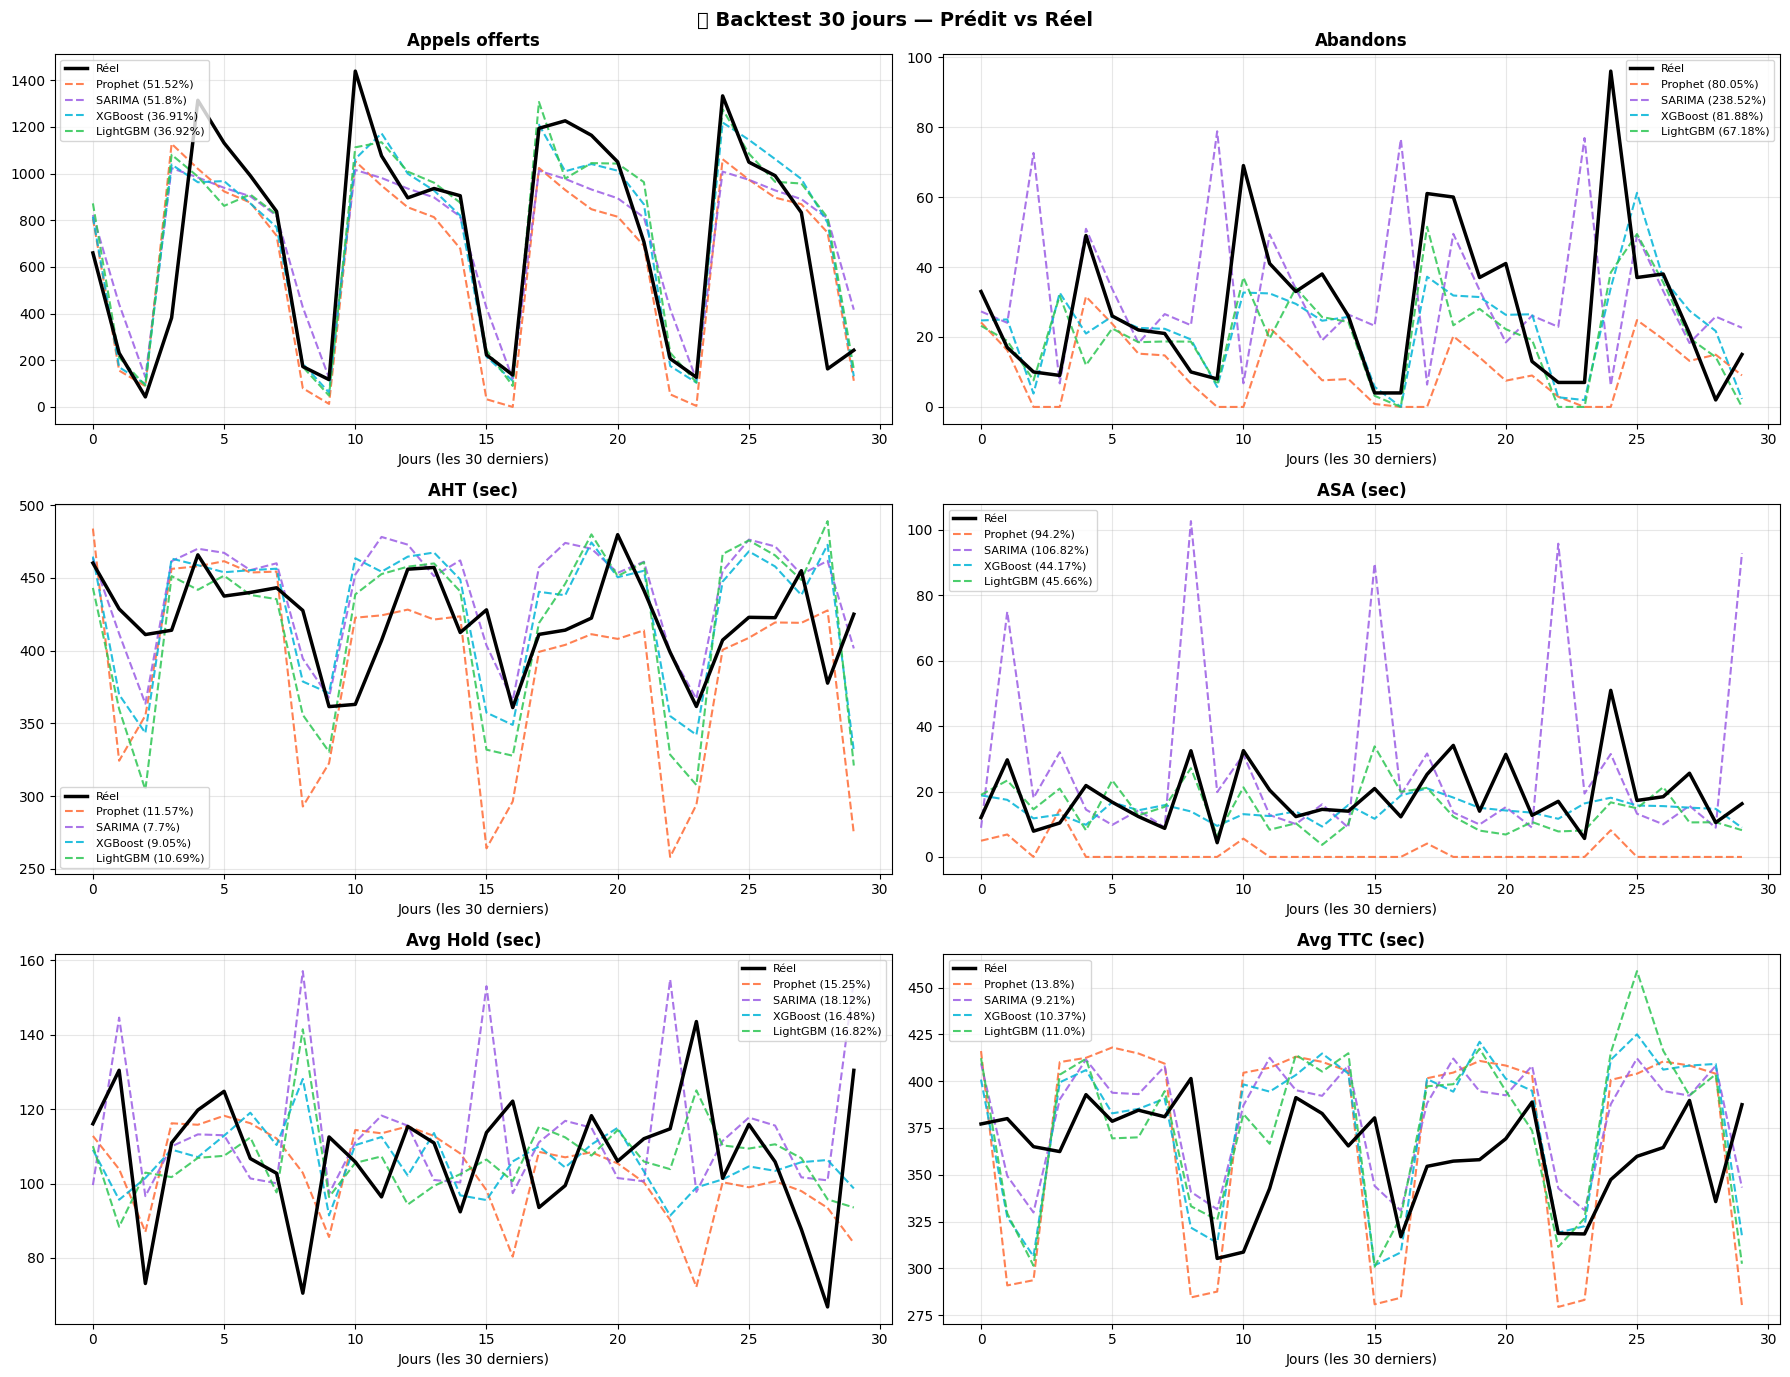

✅ backtest_comparison.png


In [12]:
fig, axes = plt.subplots(3, 2, figsize=(18, 14))
fig.suptitle('🔮 Backtest 30 jours — Prédit vs Réel', fontsize=14, fontweight='bold')
for ax, target in zip(axes.flat, TARGETS):
    y_true = all_true[target]
    x_axis = np.arange(len(y_true))
    ax.plot(x_axis, y_true, 'k-', linewidth=2.5, label='Réel', zorder=5)
    for model, fc in all_forecasts.get(target,{}).items():
        mp = all_results[target].get(model,{}).get('mape','-')
        ax.plot(x_axis, fc, '--', linewidth=1.5, color=COLORS.get(model,'gray'),
                label=f'{model} ({mp}%)', alpha=0.85)
    ax.set_title(LABELS[target], fontweight='bold')
    ax.set_xlabel('Jours (les 30 derniers)')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('backtest_comparison.png', dpi=130, bbox_inches='tight')
plt.show()
print('✅ backtest_comparison.png')

## 8. Feature importance — XGBoost & LightGBM (sur offered)

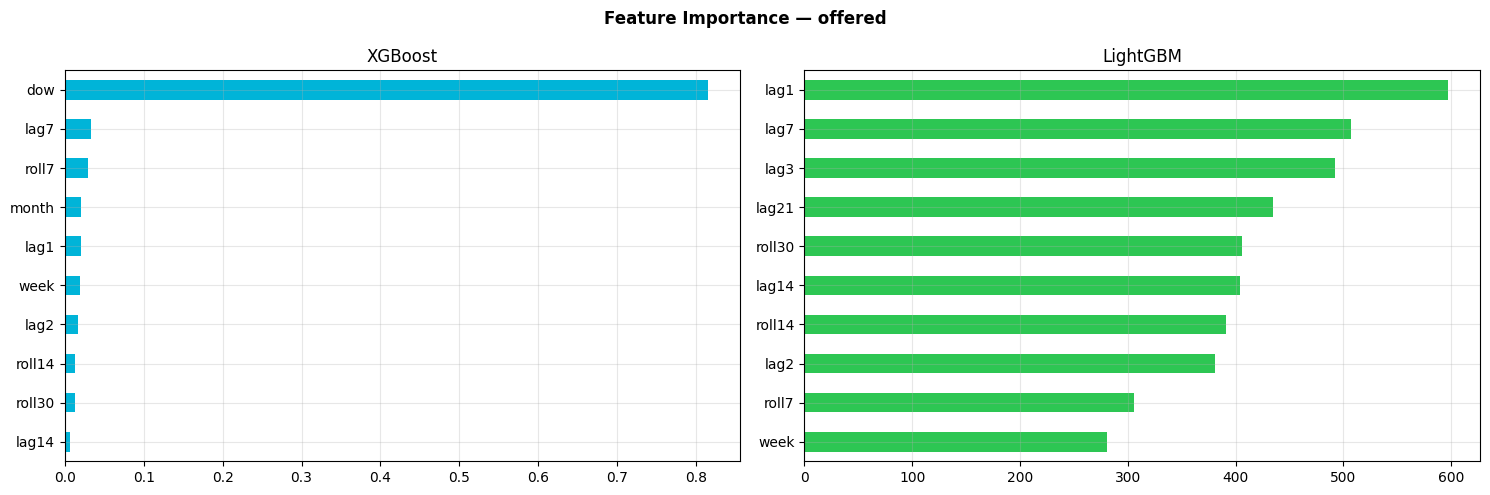

In [13]:
TARGET_FI = 'offered'
ts_fi = daily[['date',TARGET_FI]].rename(columns={'date':'ds',TARGET_FI:'y'})
ts_fi = ts_fi[ts_fi['y']>0].reset_index(drop=True)
tf_fi = make_lag_features(ts_fi)
fc_fi = [c for c in tf_fi.columns if c not in ['ds','y']]
X_fi  = tf_fi[fc_fi].values[:-HORIZON]
y_fi  = tf_fi['y'].values[:-HORIZON]

xm_fi = xgb.XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42, verbosity=0)
xm_fi.fit(X_fi, y_fi)
lm_fi = lgb.LGBMRegressor(n_estimators=300, num_leaves=31, learning_rate=0.05, random_state=42, verbose=-1)
lm_fi.fit(X_fi, y_fi)

fig, (ax1,ax2) = plt.subplots(1,2,figsize=(15,5))
fig.suptitle(f'Feature Importance — {TARGET_FI}', fontweight='bold')
pd.Series(xm_fi.feature_importances_, index=fc_fi).sort_values().tail(10).plot.barh(ax=ax1, color='#00B4D8')
ax1.set_title('XGBoost')
pd.Series(lm_fi.feature_importances_, index=fc_fi).sort_values().tail(10).plot.barh(ax=ax2, color='#2DC653')
ax2.set_title('LightGBM')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. Prévision future — 30 prochains jours

| KPI | Modèle retenu |
|-----|---------------|
| offered | XGBoost |
| abandoned | LightGBM |
| avg_aht | SARIMA |
| asa | XGBoost |
| avg_hold | Prophet |
| avg_ttc | SARIMA |

In [14]:
BEST_MODELS = {'offered':'XGBoost','abandoned':'LightGBM',
               'avg_aht':'SARIMA','asa':'XGBoost',
               'avg_hold':'Prophet','avg_ttc':'SARIMA'}
FUTURE_HORIZON = 30
future_dates = pd.date_range(daily['date'].max()+pd.Timedelta(days=1), periods=FUTURE_HORIZON, freq='D')
future_preds = {'date': future_dates}

for target, best_model in BEST_MODELS.items():
    ts = daily[['date',target]].rename(columns={'date':'ds',target:'y'})
    ts = ts[ts['y']>0].reset_index(drop=True)

    if best_model == 'Prophet':
        m = Prophet(yearly_seasonality=True, weekly_seasonality=True,
                    daily_seasonality=False, changepoint_prior_scale=0.05)
        m.fit(ts)
        fc = m.predict(m.make_future_dataframe(periods=FUTURE_HORIZON)).tail(FUTURE_HORIZON)['yhat'].values.clip(min=0)

    elif best_model == 'SARIMA':
        fit = SARIMAX(ts['y'].values, order=(1,1,1), seasonal_order=(1,1,0,7),
                      enforce_stationarity=False, enforce_invertibility=False).fit(disp=False, maxiter=80)
        fc = fit.forecast(FUTURE_HORIZON).clip(min=0)

    else:  # XGBoost / LightGBM — prédiction récursive
        tf_full = make_lag_features(ts)
        feat_cols = [c for c in tf_full.columns if c not in ['ds','y']]
        model_f = (xgb.XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05,
                                     subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0)
                   if best_model=='XGBoost' else
                   lgb.LGBMRegressor(n_estimators=300, num_leaves=31, learning_rate=0.05,
                                      subsample=0.8, random_state=42, verbose=-1))
        model_f.fit(tf_full[feat_cols].values, tf_full['y'].values)
        history = list(ts['y'].values)
        fc = []
        for i in range(FUTURE_HORIZON):
            fd = future_dates[i]
            row = [
                history[-1], history[-2], history[-3],
                history[-7] if len(history)>=7 else history[0],
                history[-14] if len(history)>=14 else history[0],
                history[-21] if len(history)>=21 else history[0],
                np.mean(history[-7:]), np.mean(history[-14:]), np.mean(history[-30:]),
                fd.dayofweek, fd.month, fd.isocalendar()[1], int(fd.dayofweek>=5)
            ]
            pred = max(float(model_f.predict([row])[0]), 0)
            fc.append(pred); history.append(pred)
        fc = np.array(fc)

    future_preds[target] = fc.round(2)
    print(f'✅ {target:12s} ({best_model}) — moy={fc.mean():.1f}')

df_future = pd.DataFrame(future_preds)
print('\n📅 Extrait prévisions :')
df_future.head(10)

✅ offered      (XGBoost) — moy=588.0
✅ abandoned    (LightGBM) — moy=22.4
✅ avg_aht      (SARIMA) — moy=410.4
✅ asa          (XGBoost) — moy=20.4


19:48:12 - cmdstanpy - INFO - Chain [1] start processing
19:48:12 - cmdstanpy - INFO - Chain [1] done processing


✅ avg_hold     (Prophet) — moy=106.0
✅ avg_ttc      (SARIMA) — moy=354.8

📅 Extrait prévisions :


,date,offered,abandoned,avg_aht,asa,avg_hold,avg_ttc
0,2026-05-03,149.07,6.54,361.41,11.74,73.16,326.83
1,2026-05-04,936.67,55.95,408.78,21.79,99.44,351.54
2,2026-05-05,815.19,30.71,417.75,15.99,99.18,358.74
3,2026-05-06,807.69,20.48,421.94,22.32,101.93,361.62
4,2026-05-07,691.80,30.20,467.29,32.02,99.52,381.39
5,2026-05-08,512.15,18.35,410.35,11.44,95.65,355.34
6,2026-05-09,137.15,6.17,410.79,17.26,89.02,360.76
7,2026-05-10,100.69,1.17,361.00,13.53,73.53,323.07
8,2026-05-11,996.76,51.67,407.46,32.89,101.03,349.41
9,2026-05-12,885.89,36.43,419.90,30.15,102.02,358.60


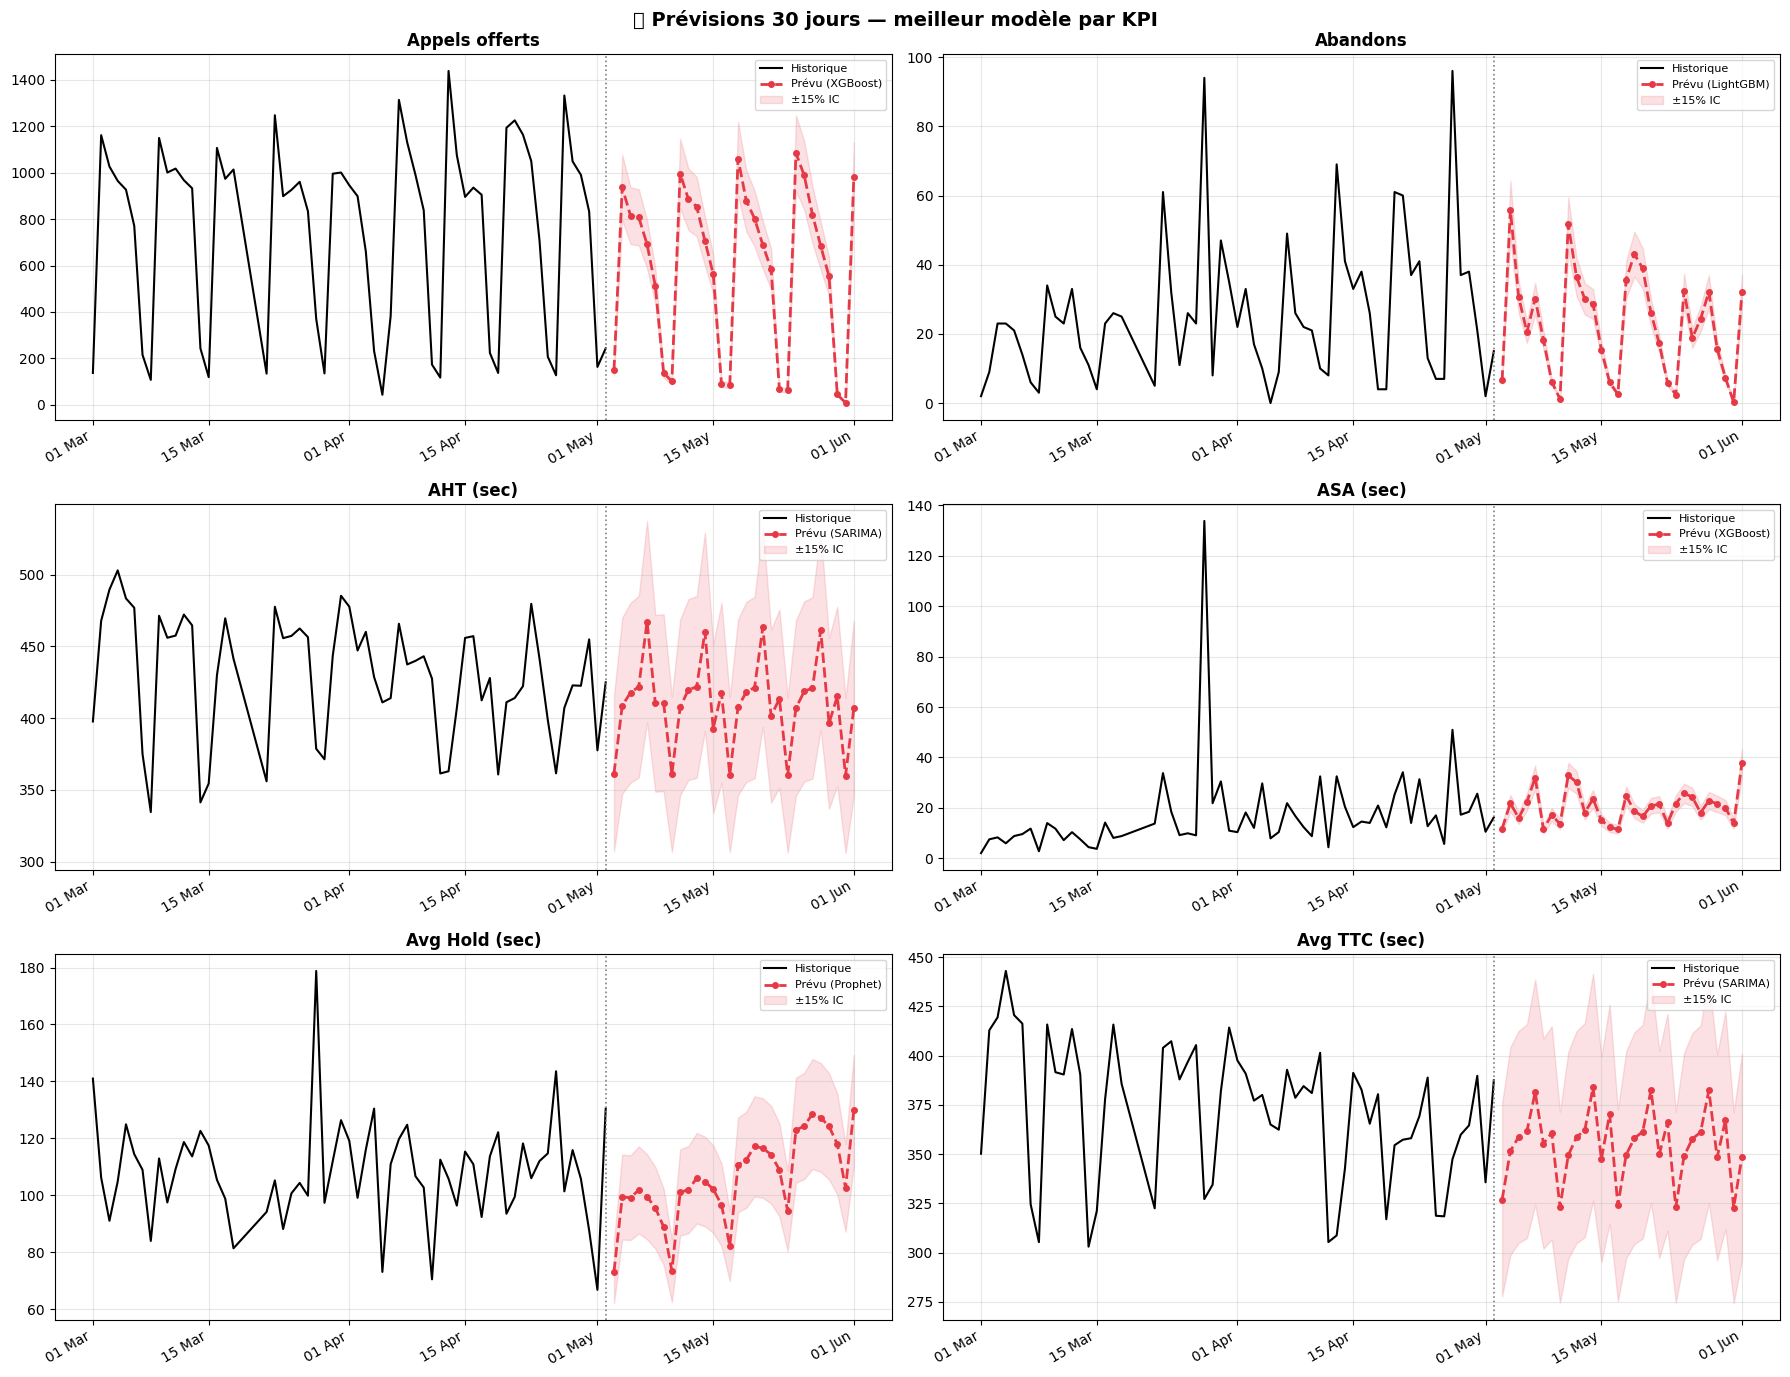

✅ forecast_30days.png


In [15]:
fig, axes = plt.subplots(3, 2, figsize=(18, 14))
fig.suptitle('📅 Prévisions 30 jours — meilleur modèle par KPI', fontsize=14, fontweight='bold')
LOOKBACK = 60

for ax, target in zip(axes.flat, TARGETS):
    hist = daily[['date',target]].tail(LOOKBACK)
    ax.plot(hist['date'], hist[target], 'k-', linewidth=1.5, label='Historique')
    fc_vals = df_future[target].values
    ax.plot(future_dates, fc_vals, '--o', linewidth=2, markersize=4,
            color='#E63946', label=f'Prévu ({BEST_MODELS[target]})')
    ax.fill_between(future_dates, fc_vals*0.85, fc_vals*1.15,
                    alpha=0.15, color='#E63946', label='±15% IC')
    ax.axvline(daily['date'].max(), color='gray', linestyle=':', linewidth=1.2)
    ax.set_title(LABELS[target], fontweight='bold')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig('forecast_30days.png', dpi=130, bbox_inches='tight')
plt.show()
print('✅ forecast_30days.png')

In [16]:
df_future.to_csv('predictions_30days.csv', index=False)
print('✅ Prévisions exportées : predictions_30days.csv')
df_future

✅ Prévisions exportées : predictions_30days.csv


,date,offered,abandoned,avg_aht,asa,avg_hold,avg_ttc
0,2026-05-03,149.07,6.54,361.41,11.74,73.16,326.83
1,2026-05-04,936.67,55.95,408.78,21.79,99.44,351.54
2,2026-05-05,815.19,30.71,417.75,15.99,99.18,358.74
3,2026-05-06,807.69,20.48,421.94,22.32,101.93,361.62
4,2026-05-07,691.80,30.20,467.29,32.02,99.52,381.39
5,2026-05-08,512.15,18.35,410.35,11.44,95.65,355.34
6,2026-05-09,137.15,6.17,410.79,17.26,89.02,360.76
7,2026-05-10,100.69,1.17,361.00,13.53,73.53,323.07
8,2026-05-11,996.76,51.67,407.46,32.89,101.03,349.41
9,2026-05-12,885.89,36.43,419.90,30.15,102.02,358.60


---
## 📌 Conclusion

| KPI | Meilleur | MAPE | Verdict |
|-----|----------|------|---|
| **offered** | XGBoost | 35.8% | Variance weekend forte → modèle BH/OOH séparé conseillé |
| **abandoned** | LightGBM | 75.6% | Très volatil — hard à prédire sans features externes |
| **avg_aht** | **SARIMA** | **7.7%** | ✅ Excellent — stable et prévisible |
| **asa** | XGBoost | 50.5% | Lié à offered — s'améliore si offered est mieux prédit |
| **avg_hold** | **Prophet** | **15.2%** | ✅ Bon — saisonnalité hebdo bien capturée |
| **avg_ttc** | **SARIMA** | **9.2%** | ✅ Excellent — le plus stable |

### Pistes d'amélioration :
1. **Séparer BH / OOH** — volumes structurellement différents
2. **Modèles par account** — chaque compte a son pattern
3. **Ensembling SARIMA + XGBoost** — souvent meilleur sur offered
4. **Ajouter les jours fériés** — `m.add_country_holidays('FR')` dans Prophet
5. **LSTM** — pertinent si > 2 ans de données par queue
